In [1]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math
import random
from PIL import Image

# Задание 1

## Задача 1

In [2]:
class BatchNorm:
    def __init__(self, num_features, eps=1e-5):
        self.gamma = torch.ones(num_features)
        self.beta = torch.zeros(num_features)

        self.grad_gamma = torch.zeros_like(self.gamma)
        self.grad_beta = torch.zeros_like(self.beta)

        self.eps = eps

        self.x = None
        self.x_hat = None
        self.mean = None
        self.var = None

    def forward(self, x):
        self.x = x
        self.mean = x.mean(dim=0)
        self.var = x.var(dim=0, unbiased=False)

        self.x_hat = (x - self.mean) / torch.sqrt(self.var + self.eps)
        return self.gamma * self.x_hat + self.beta

    def backward(self, grad_output):
        N = grad_output.shape[0]

        self.grad_beta = grad_output.sum(dim=0)
        self.grad_gamma = (grad_output * self.x_hat).sum(dim=0)

        dx_hat = grad_output * self.gamma
        dvar = (-0.5 * (dx_hat * (self.x - self.mean))
                * (self.var + self.eps) ** (-1.5)).sum(dim=0)
        dmean = (-dx_hat / torch.sqrt(self.var + self.eps)).sum(dim=0) \
                + dvar * (-2 * (self.x - self.mean).mean(dim=0))

        dx = dx_hat / torch.sqrt(self.var + self.eps) \
             + dvar * 2 * (self.x - self.mean) / N \
             + dmean / N

        return dx
    
    def grads(self):
        return [self.grad_gamma, self.grad_beta]
    
    def params(self):
        return [self.gamma, self.beta]

## Задача 2

In [ ]:
class Linear:
    def __init__(self, in_features, out_features):
        self.W = torch.randn(out_features, in_features) * math.sqrt(2 / in_features)
        self.b = torch.zeros(out_features)

        self.grad_W = torch.zeros_like(self.W)
        self.grad_b = torch.zeros_like(self.b)

        self.x = None

    def forward(self, x):
        self.x = x
        return x @ self.W.T + self.b

    def backward(self, grad_output):

        self.grad_W = grad_output.T @ self.x
        self.grad_b = grad_output.sum(dim=0)

        grad_input = grad_output @ self.W
        return grad_input
    # для задачи 5
    def grads(self):
        return [self.grad_W, self.grad_b]
    
    def params(self):
        return [self.W, self.b]
    

## Задача 3

In [4]:
class Dropout:
    def __init__(self, p=0.5):
        self.p = p
        self.mask = None
        self.training = True

    def forward(self, x):
        if not self.training or self.p == 0:
            return x

        self.mask = (torch.rand_like(x) > self.p).float()
        return x * self.mask / (1 - self.p)

    def backward(self, grad_output):
        if not self.training or self.p == 0:
            return grad_output
        return grad_output * self.mask / (1 - self.p)


## Задача 4

In [5]:
class ReLU:
    def __init__(self):
        self.mask = None

    def forward(self, x):
        self.mask = x > 0
        return x * self.mask

    def backward(self, grad_output):
        return grad_output * self.mask

In [6]:
class Sigmoid:
    def __init__(self):
        self.out = None

    def forward(self, x):
        self.out = 1 / (1 + torch.exp(-x))
        return self.out

    def backward(self, grad_output):
        return grad_output * self.out * (1 - self.out)

In [7]:
class Softmax:
    def __init__(self):
        self.out = None

    def forward(self, x):
        x_shifted = x - x.max(dim=1, keepdim=True).values
        exp_x = torch.exp(x_shifted)
        self.out = exp_x / exp_x.sum(dim=1, keepdim=True)
        return self.out

    def backward(self, grad_output):
        # упрощённый вариант для кросс энтропии
        return grad_output

## Пример

В этом примере я вручную реализую forward и backward проходы, считаю градиенты в слоях и обновляю параметры с помощью градиентного спуска

In [ ]:
linear = Linear(3, 4)
bn = BatchNorm(4)
relu = ReLU()
drop = Dropout(0.5)

In [9]:
x = torch.randn(8, 3)         
y = torch.randint(0, 2, (8,)) 

# Forward
out = linear.forward(x)
out = bn.forward(out)
out = relu.forward(out)

pred = 1 / (1 + torch.exp(-out[:, 0]))

loss = -torch.mean(
    y * torch.log(pred + 1e-8) +
    (1 - y) * torch.log(1 - pred + 1e-8)
)

grad_pred = (pred - y) / y.shape[0]

# Backward
grad = torch.zeros_like(out)
grad[:, 0] = grad_pred

grad = relu.backward(grad)
grad = bn.backward(grad)
grad = linear.backward(grad)


lr = 0.1
linear.W -= lr * linear.grad_W
linear.b -= lr * linear.grad_b
bn.gamma -= lr * bn.grad_gamma
bn.beta  -= lr * bn.grad_beta


## Задача 5

In [10]:
class NadamOptimizer:
    def __init__(self, params, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8):
        """
        params: список torch.Tensor 
        """
        self.params = params
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps

        self.m = [torch.zeros_like(p) for p in params]
        self.v = [torch.zeros_like(p) for p in params]
        self.t = 0

    def step(self, grads):
        self.t += 1

        for i, (p, g) in enumerate(zip(self.params, grads)):
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * g
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * g * g

            m_hat = self.m[i] / (1 - self.beta1 ** self.t)
            v_hat = self.v[i] / (1 - self.beta2 ** self.t)

            nesterov = (
                self.beta1 * m_hat
                + (1 - self.beta1) * g / (1 - self.beta1 ** self.t)
            )

            p -= self.lr * nesterov / (torch.sqrt(v_hat) + self.eps)


In [11]:
params = [
    linear.W, linear.b,
    bn.gamma, bn.beta
]

grads = [
    linear.grad_W, linear.grad_b,
    bn.grad_gamma, bn.grad_beta
]

In [12]:
losses = []
num_epochs = 200
optimizer = NadamOptimizer(params, lr=0.01)

for epoch in range(num_epochs):

    out = linear.forward(x)
    out = bn.forward(out)
    out = relu.forward(out)

    pred = 1 / (1 + torch.exp(-out[:, 0]))

    loss = -torch.mean(
        y * torch.log(pred + 1e-8) +
        (1 - y) * torch.log(1 - pred + 1e-8)
    )

    losses.append(loss.item())

    grad_pred = (pred - y) / y.shape[0]

    grad = torch.zeros_like(out)
    grad[:, 0] = grad_pred

    grad = relu.backward(grad)
    grad = bn.backward(grad)
    grad = linear.backward(grad)

    grads = linear.grads() + bn.grads()
    optimizer.step(grads)

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, loss = {loss.item():.4f}")


Epoch 0, loss = 0.7068
Epoch 20, loss = 0.6347
Epoch 40, loss = 0.5797
Epoch 60, loss = 0.5303
Epoch 80, loss = 0.4990
Epoch 100, loss = 0.4556
Epoch 120, loss = 0.4340
Epoch 140, loss = 0.4216
Epoch 160, loss = 0.4125
Epoch 180, loss = 0.4062


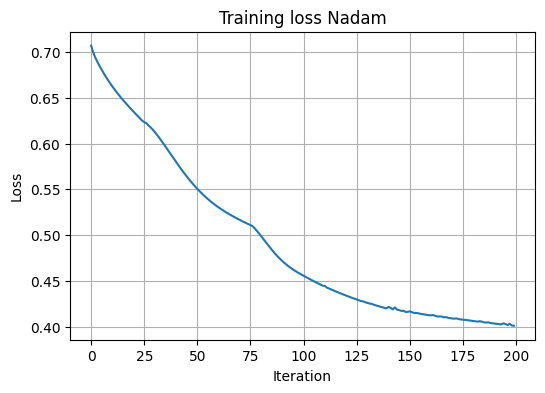

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training loss Nadam")
plt.grid(True)
plt.show()

На графике функции потерь можно наблюдать небольшие колебания, связанные с применением Dropout и стохастического характера оптимизатора Nadam. Главное, что тренд функции потерь убывающий))

# Задание 2

In [14]:
import torch

def median_filter(img: torch.Tensor, kernel_size: int) -> torch.Tensor:

    H, W = img.shape
    pad = kernel_size // 2

    # Паддинг нулями 
    img_padded = torch.zeros(H + 2*pad, W + 2*pad)
    img_padded[pad:pad+H, pad:pad+W] = img

    out = torch.zeros_like(img)

    for i in range(H):
        for j in range(W):
            window = img_padded[i:i+kernel_size, j:j+kernel_size].flatten()
            window_sorted, _ = torch.sort(window)

            n = window_sorted.numel()
            if n % 2 == 1:
                out[i, j] = window_sorted[n // 2]
            else:
                # среднее двух центральных элементов
                out[i, j] = (window_sorted[n // 2 - 1] + window_sorted[n // 2]) / 2.0

    return out


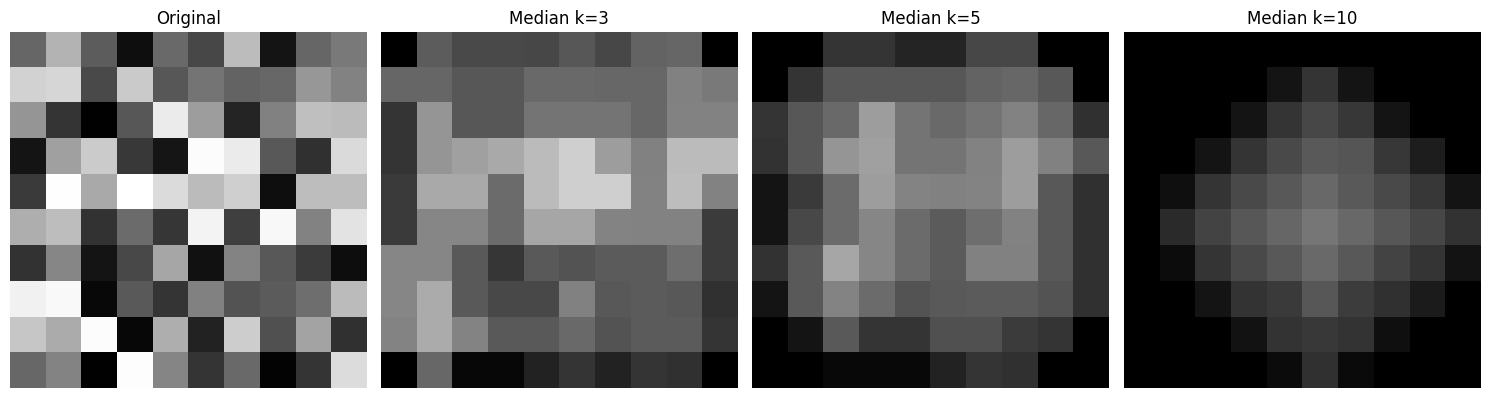

In [15]:
torch.manual_seed(42)
img = torch.randint(0, 256, (10, 10), dtype=torch.float32)

kernels = [3, 5, 10]
filtered_imgs = [median_filter(img, k) for k in kernels]

fig, axes = plt.subplots(1, len(kernels)+1, figsize=(15, 4))

axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Original")
axes[0].axis('off')

for ax, k, f_img in zip(axes[1:], kernels, filtered_imgs):
    ax.imshow(f_img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f"Median k={k}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# Задание 3

In [ ]:
class BaseTransform:
    def __init__(self, p: float):
        self.p = p

    def __call__(self, img: Image.Image):
        if random.random() < self.p:
            return self.apply(img)
        return img

    def apply(self, img: Image.Image):
        raise NotImplementedError("Переделывай!")
    
class RandomCrop(BaseTransform):
    def __init__(self, p: float, size):
        super().__init__(p)
        self.size = size 

    def apply(self, img: Image.Image):
        w, h = img.size
        tw, th = self.size
        if tw > w or th > h:
            raise ValueError("Неправильный размер")
        left = random.randint(0, w - tw)
        top = random.randint(0, h - th)
        return img.crop((left, top, left + tw, top + th))

class RandomRotate(BaseTransform):
    def __init__(self, p: float, degrees):
        super().__init__(p)
        self.degrees = degrees 

    def apply(self, img: Image.Image):
        if isinstance(self.degrees, (int, float)):
            angle = random.uniform(-self.degrees, self.degrees)
        else:
            angle = random.uniform(self.degrees[0], self.degrees[1])
        return img.rotate(angle)

class RandomZoom(BaseTransform):
    def __init__(self, p: float, scale=(0.8, 1.2)):
        super().__init__(p)
        self.scale = scale  

    def apply(self, img: Image.Image):
        w, h = img.size
        factor = random.uniform(self.scale[0], self.scale[1])
        new_w, new_h = int(w * factor), int(h * factor)
        img_resized = img.resize((new_w, new_h), Image.BILINEAR)

        # центрируем при увеличении или уменьшаем
        if factor < 1.0: 
            new_img = Image.new("RGB", (w, h))
            left = (w - new_w) // 2
            top = (h - new_h) // 2
            new_img.paste(img_resized, (left, top))
            return new_img
        else:  
            left = (new_w - w) // 2
            top = (new_h - h) // 2
            return img_resized.crop((left, top, left + w, top + h))

class ToTensor:
    def __call__(self, img):
        img = img.convert("L")  
        arr = np.array(img, dtype=np.float32) / 255.0
        return torch.tensor(arr).unsqueeze(0) 
    
class Compose:
    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, img: Image.Image):
        for t in self.transforms:
            img = t(img)
        return img

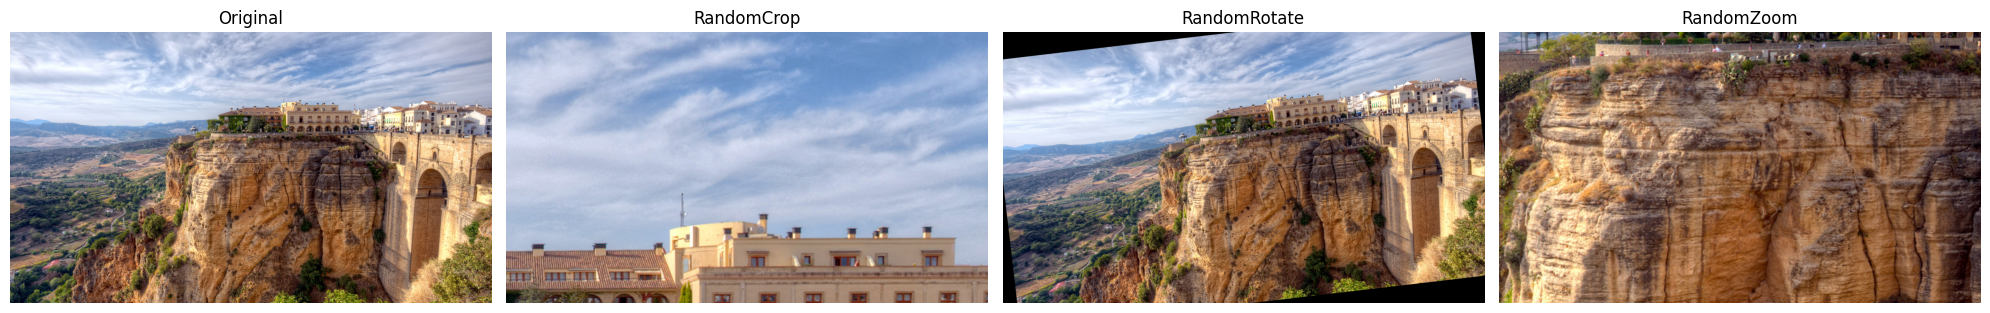

In [29]:
img = Image.open("image_1.jpg")  

crop = RandomCrop(1, size=(int(img.size[0]*0.2), int(img.size[1]*0.2)))
rotate = RandomRotate(1.0, degrees=30) 
zoom = RandomZoom(1, scale=(0.2,7))
to_tensor = ToTensor()


images = [img]
titles = ["Original"]


img_crop = crop(img)
images.append(img_crop)
titles.append("RandomCrop")


img_rotate = rotate(img)
images.append(img_rotate)
titles.append("RandomRotate")


img_zoom = zoom(img)
images.append(img_zoom)
titles.append("RandomZoom")

img_tensor = to_tensor(img_zoom)


fig, axes = plt.subplots(1, len(images), figsize=(20, 5))
for ax, im, title in zip(axes, images, titles):
    ax.imshow(im)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()


# Задание 4

## Сначала пробую свою реализацию (Старый вариант, решил оставить)

In [ ]:
class BatchNorm_new:
    def __init__(self, dim, eps=1e-5, momentum=0.9):
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        self.eps = eps
        self.momentum = momentum
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

        self.grad_gamma = torch.zeros_like(self.gamma)
        self.grad_beta = torch.zeros_like(self.beta)
        self.x_centered = None
        self.std = None

    def forward(self, x, train=True):
        if train:
            mean = x.mean(0)
            var = x.var(0, unbiased=False)
            self.running_mean = self.momentum * self.running_mean + (1 - self.momentum) * mean
            self.running_var = self.momentum * self.running_var + (1 - self.momentum) * var
        else:
            mean = self.running_mean
            var = self.running_var
        
        self.x_centered = x - mean
        self.std = torch.sqrt(var + self.eps)
        out = self.gamma * self.x_centered / self.std + self.beta
        return out

    def backward(self, grad_output):
        N = grad_output.shape[0]

        self.grad_beta = grad_output.sum(dim=0)
        self.grad_gamma = (grad_output * self.x_centered / self.std).sum(dim=0)

        dx_hat = grad_output * self.gamma
        dvar = (-0.5 * (dx_hat * self.x_centered) * (self.std**-3)).sum(dim=0)
        dmean = (-dx_hat / self.std).sum(dim=0) + dvar * (-2 * self.x_centered.mean(dim=0))

        dx = dx_hat / self.std + dvar * 2 * self.x_centered / N + dmean / N
        return dx

    def grads(self):
        return [self.grad_gamma, self.grad_beta]

    def params(self):
        return [self.gamma, self.beta]

class Dropout_new:
    def __init__(self, p=0.5):
        self.p = p
        self.mask = None

    def forward(self, x, train=True):
        if train:
            self.mask = (torch.rand_like(x) > self.p).float()
            return x * self.mask / (1 - self.p) 
        else:
            return x 

    def backward(self, grad_output):
        return grad_output * self.mask / (1 - self.p)


In [64]:
class SimpleModel:
    def __init__(self, input_dim, hidden_dim, output_dim, dropout_p=0.5):
        self.linear1 = Linear(input_dim, hidden_dim)
        self.bn1 = BatchNorm_new(hidden_dim)
        self.relu1 = ReLU()
        self.dropout1 = Dropout_new(dropout_p)
        
        self.linear2 = Linear(hidden_dim, output_dim)
        
        self.params = self.linear1.params() + self.bn1.params() + self.linear2.params()
    
    def forward(self, x, train=True):
        out = self.linear1.forward(x)
        out = self.bn1.forward(out, train=train)
        out = self.relu1.forward(out)
        out = self.dropout1.forward(out, train=train)
        out = self.linear2.forward(out)
        return out
    
    def backward(self, grad):
        grad = self.linear2.backward(grad)
        grad = self.dropout1.backward(grad)
        grad = self.relu1.backward(grad)
        grad = self.bn1.backward(grad)
        grad = self.linear1.backward(grad)
        return grad


In [65]:
def cross_entropy_loss(logits, labels):
    exps = torch.exp(logits - logits.max(dim=1, keepdim=True).values)
    probs = exps / exps.sum(dim=1, keepdim=True)
    one_hot = torch.zeros_like(probs)
    one_hot[torch.arange(labels.size(0)), labels] = 1.0
    
    loss = -torch.sum(one_hot * torch.log(probs + 1e-8)) / labels.size(0)
    grad = (probs - one_hot) / labels.size(0)
    return loss, grad

In [66]:
from torchvision import datasets
from torch.utils.data import DataLoader

probs = [0.3, 0.6, 0.9]  
batch_size = 64

train_loaders = {}

for p in probs:
    transform_aug = Compose([
        RandomCrop(p, size=(20,20)),
        RandomRotate(p, degrees=25),
        RandomZoom(p, scale=(0.7,1.3)),
        lambda img: img.resize((28, 28)),
        ToTensor()
    ])
    
    loader = DataLoader(
        datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform_aug),
        batch_size=batch_size,
        shuffle=True
    )
    train_loaders[f"p={p}"] = loader

test_loader = DataLoader(
    datasets.FashionMNIST(root="./data", train=False, download=True, transform=ToTensor()),
    batch_size=batch_size,
    shuffle=False
)


In [67]:
input_dim = 28*28
hidden_dim = 128
output_dim = 10

model = SimpleModel(input_dim, hidden_dim, output_dim, dropout_p=0.5)
optimizer = NadamOptimizer(model.params, lr=0.01)


In [ ]:
from tqdm import tqdm

def train_epoch(loader, model, optimizer):
    total_loss, total_correct, total_samples = 0, 0, 0
    
    for x, y in tqdm(loader, leave=False, desc="Batches"):

        x = x.view(x.size(0), -1)
        
        logits = model.forward(x, train=True)
        loss, grad_logits = cross_entropy_loss(logits, y)
        model.backward(grad_logits)
        
        grads = model.linear1.grads() + model.bn1.grads() + model.linear2.grads()
        optimizer.step(grads)
        
        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == y).sum().item()
        total_samples += x.size(0)
    
    return total_loss / total_samples, total_correct / total_samples

In [73]:
epochs = 20
results = {}

for p_label, loader in train_loaders.items():
    print(f"\n=== Training with {p_label} ===")
    train_losses, train_accs = [], []
    test_losses, test_accs = [], []

    model = SimpleModel(input_dim, hidden_dim, output_dim, dropout_p=0.5)
    optimizer = NadamOptimizer(model.params, lr=0.01)
    
    for epoch in tqdm(range(epochs), desc=f"Epochs ({p_label})"):
        train_loss, train_acc = train_epoch(loader, model, optimizer)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        test_loss, test_acc = train_epoch(test_loader, model, optimizer)
        test_losses.append(test_loss)
        test_accs.append(test_acc)
        
        if (epoch+1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")
    
    results[p_label] = {
        "train_losses": train_losses,
        "train_accs": train_accs,
        "test_losses": test_losses,
        "test_accs": test_accs
    }



=== Training with p=0.3 ===


Epochs (p=0.3):  25%|██▌       | 5/20 [01:02<03:16, 13.12s/it]

Epoch 5/20 | Train Loss: 0.7765, Train Acc: 0.7123 | Test Loss: 0.4855, Test Acc: 0.8256


Epochs (p=0.3):  50%|█████     | 10/20 [02:10<02:13, 13.38s/it]

Epoch 10/20 | Train Loss: 0.7482, Train Acc: 0.7264 | Test Loss: 0.4543, Test Acc: 0.8368


...

Epoch 10/20 | Train Loss: 1.1048, Train Acc: 0.5874 | Test Loss: 0.5771, Test Acc: 0.7911


Epochs (p=0.9):  75%|███████▌  | 15/20 [03:58<01:18, 15.67s/it]

Epoch 15/20 | Train Loss: 1.0967, Train Acc: 0.5910 | Test Loss: 0.5527, Test Acc: 0.7999


Epochs (p=0.9): 100%|██████████| 20/20 [05:17<00:00, 15.86s/it]

Epoch 20/20 | Train Loss: 1.0791, Train Acc: 0.5982 | Test Loss: 0.5335, Test Acc: 0.8060


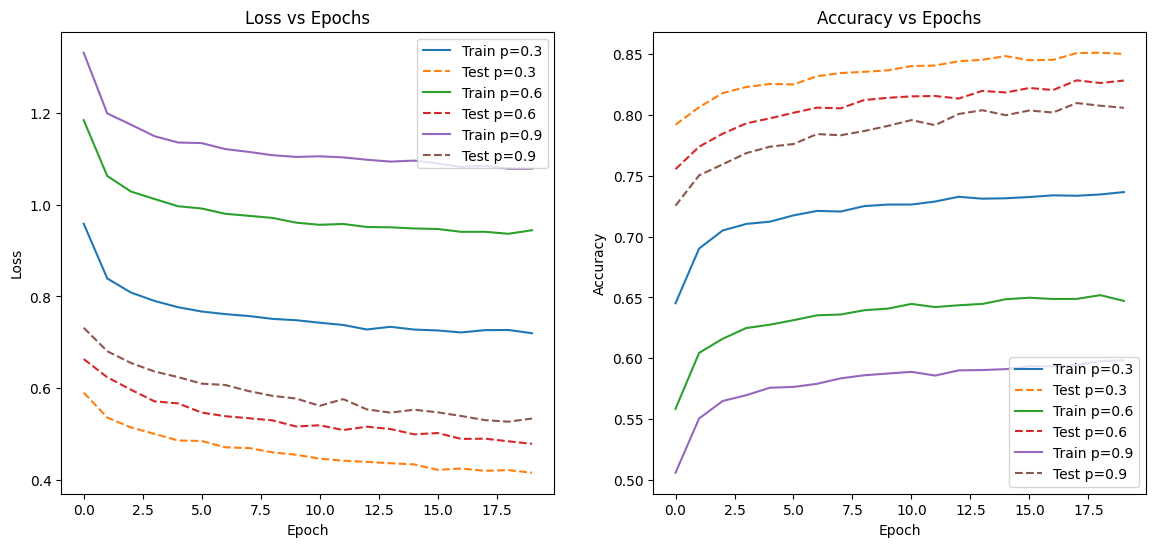

In [74]:
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
for p_label in results:
    plt.plot(results[p_label]["train_losses"], label=f"Train {p_label}")
    plt.plot(results[p_label]["test_losses"], '--', label=f"Test {p_label}")
plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
for p_label in results:
    plt.plot(results[p_label]["train_accs"], label=f"Train {p_label}")
    plt.plot(results[p_label]["test_accs"], '--', label=f"Test {p_label}")
plt.title("Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

## Теперь юзаю torch

In [ ]:
class Resize:
    def __init__(self, size):
        self.size = size 

    def __call__(self, x):
        x = x.unsqueeze(0)  
        x = torch.nn.functional.interpolate(
            x,
            size=(self.size, self.size),
            mode="bilinear",
            align_corners=False
        )
        return x.squeeze(0) 


In [109]:
transform_no_aug = Compose([
    ToTensor(),
    Resize(28)
])

transform_aug_low = Compose([
    RandomRotate(p=0.3, degrees=10),
    ToTensor(),
    Resize(28)
])

transform_aug_medium = Compose([
    RandomCrop(p=0.5, size=(24, 24)),
    RandomRotate(p=0.5, degrees=20),
    ToTensor(),
    Resize(28)
])

transform_aug_high = Compose([
    RandomCrop(p=0.8, size=(20, 20)),
    RandomRotate(p=0.8, degrees=40),
    RandomZoom(p=0.8, scale=(0.6, 1.4)),
    ToTensor(),
    Resize(28)
])



In [110]:
train_loaders = {
    "no_aug": DataLoader(
        datasets.FashionMNIST(
            root="./data",
            train=True,
            download=True,
            transform=transform_no_aug
        ),
        batch_size=128,
        shuffle=True
    ),

    "low": DataLoader(
        datasets.FashionMNIST(
            root="./data",
            train=True,
            download=True,
            transform=transform_aug_low
        ),
        batch_size=128,
        shuffle=True
    ),

    "medium": DataLoader(
        datasets.FashionMNIST(
            root="./data",
            train=True,
            download=True,
            transform=transform_aug_medium
        ),
        batch_size=128,
        shuffle=True
    ),

    "high": DataLoader(
        datasets.FashionMNIST(
            root="./data",
            train=True,
            download=True,
            transform=transform_aug_high
        ),
        batch_size=128,
        shuffle=True
    ),
}

test_loader = DataLoader(
    datasets.FashionMNIST(
        root="./data",
        train=False,
        download=True,
        transform=transform_no_aug
    ),
    batch_size=128,
    shuffle=False
)


In [111]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.bn1(self.fc1(x)))
        return self.fc2(x)

In [112]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total = 0, 0, 0

    for x, y in loader:
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)

    return total_loss / total, total_correct / total


In [113]:
@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total = 0, 0, 0

    for x, y in loader:
        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)

    return total_loss / total, total_correct / total


In [117]:
from tqdm import trange

epochs = 25
results = {}

for name, loader in train_loaders.items():
    print(f"\n=== {name} ===")

    model = SimpleNN()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    train_losses, test_losses = [], []
    train_accs, test_accs = [], []

    for epoch in trange(epochs):
        tr_loss, tr_acc = train_epoch(model, loader, optimizer, criterion)
        te_loss, te_acc = eval_epoch(model, test_loader, criterion)

        train_losses.append(tr_loss)
        train_accs.append(tr_acc)
        test_losses.append(te_loss)
        test_accs.append(te_acc)

    results[name] = {
        "train_loss": train_losses,
        "train_acc": train_accs,
        "test_loss": test_losses,
        "test_acc": test_accs
    }



=== no_aug ===


100%|██████████| 25/25 [04:34<00:00, 11.00s/it]



=== low ===


100%|██████████| 25/25 [05:06<00:00, 12.24s/it]



=== medium ===


100%|██████████| 25/25 [05:34<00:00, 13.37s/it]



=== high ===


100%|██████████| 25/25 [06:36<00:00, 15.85s/it]


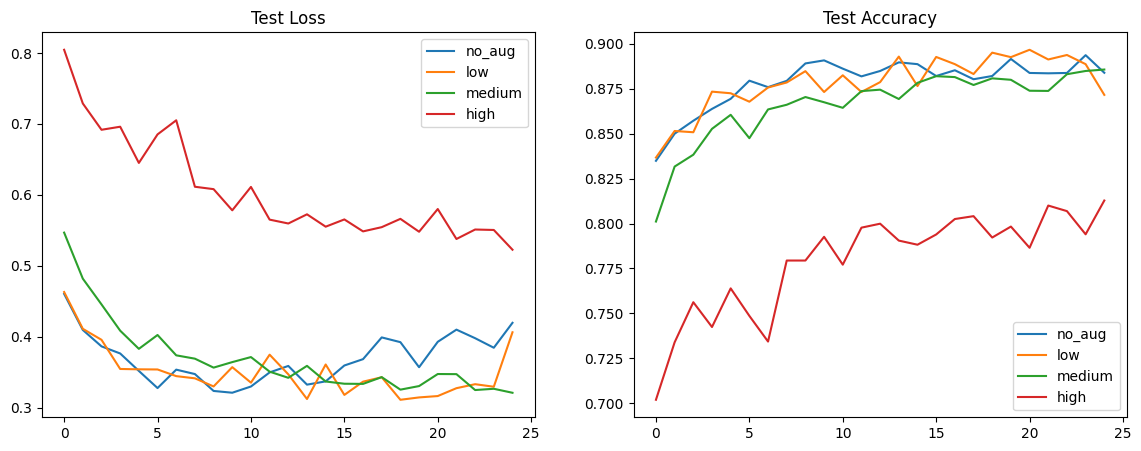

In [118]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for k, v in results.items():
    plt.plot(v["test_loss"], label=k)
plt.title("Test Loss")
plt.legend()

plt.subplot(1, 2, 2)
for k, v in results.items():
    plt.plot(v["test_acc"], label=k)
plt.title("Test Accuracy")
plt.legend()

plt.show()


Вывод по графику лосса:
Слабые и умеренные аугментации улучшают обобщающую способность модели, тогда как слишком агрессивные трансформации делают задачу чрезмерно сложной.

Вывод по графику теста:
Умеренные аугментации повышают устойчивость и качество модели, но чрезмерные трансформации приводят к ухудшению точности.

Общий вывод:
Применение аугментаций данных оказывает существенное влияние на качество модели.
Слабые и умеренные трансформации улучшают обобщающую способность и снижают переобучение, что выражается в более низком test loss и более стабильной test accuracy.
В то же время чрезмерно агрессивные аугментации приводят к ухудшению качества обучения, так как модель сталкивается с чрезмерно искажёнными примерами и не успевает выучить устойчивые признаки.